# Mapping the Narrative Journey: A Structural Analysis of Podcast Conversations

**Notebook:** Initial analysis, testing, and implementation of semantic segmentation and topic modeling pipelines.

**Dataset:** SPoRC (Podcast Corpus)

**Goal:** Develop and evaluate methods to segment podcast transcripts into coherent narrative units.

In [ ]:
%pip install -r requirements.txt

## Global imports

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import nltk
from nltk.tokenize import sent_tokenize
from sklearn.metrics.pairwise import cosine_similarity
from scipy.signal import find_peaks
#nltk.download("punkt")

# For topic modeling, graph modeling, visualization
from sklearn.cluster import KMeans
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
import networkx as nx
import plotly.graph_objects as go

# Analytical Pipeline

**This is an analysis project that applies a sequence of existing NLP techniques to generate novel insights.**

- **Semantic Segmentation:** Transcripts will first be divided into coherent topical segments using text similarity algorithms, identifying natural breakpoints in the conversation.

- **Topic Labeling:** Each segment will be assigned a concise topic label using a powerful topic modeling technique like BERTopic or a Large Language Model for high-quality, human-readable labels.

- **Graph Modeling:** The sequence of topics will be modeled as a directed graph, where nodes represent topics and weighted edges represent the transitions between them. The NetworkX library can be an option for this analysis.

- **Visualization:** The conversational journey will be visualized using topic-flow diagrams (e.g., Sankey diagrams) and graph plots to make the narrative structure intuitive and easy to interpret.

---

Following sections will follow this pipeline Starting with ***Loading the dataset***

## Load and Explore Data

#### Load the full SPoRC dataset

In [159]:
# Load the SPoRC dataset (12G!)
#dataset = load_dataset("blitt/SPoRC")

#### Load sample subset of the SPoRC dataset

In [3]:
# Path to your sample file
#file_path = r"C:\Users\naja\SynologyDrive\01 Skole\03 AU\7. Semester\Natural Language Processing\Project\episodeLevelDataSample.jsonl"
#dataset_sample = pd.read_json(file_path, lines=True) # Reads JSONL line by line
file_path_episode = r"C:\Users\Sadik\Desktop\NLP Project\episodeLevelDataSample.jsonl"
#file_path_spkr = r"C:\Users\Sadik\Desktop\NLP Project\speakerTurnDataSample.jsonl"
dataset_sample = pd.read_json(file_path_episode, lines=True) # Reads JSONL line by line
#spkr_data = pd.read_json(file_path_spkr, lines=True)

In [4]:
# print(f"Number of episodes: {len(dataset_sample)}")
# print(f"Columns: \n{list(dataset_sample.columns)}")
dataset_sample.head(2)
#dataset_sample.info()
# spkr_data.head()

,transcript,rssUrl,epTitle,epDescription,mp3url,podTitle,lastUpdate,itunesAuthor,itunesOwnerName,explicit,...,neitherPredictedNames,numUniqueNeithers,mainEpSpeakers,numMainSpeakers,hostSpeakerLabels,guestSpeakerLabels,overlapPropTurnCount,avgTurnDuration,overlapPropDuration,totalSpLabels
0,I'm Simon Shapiro and this is Sing Out Speak ...,https://feeds.buzzsprout.com/783020.rss,Best of SingOut SpeakOut No.3,<p>Best of with snippets from 3 episodes and a...,https://www.buzzsprout.com/783020/4252475-best...,SingOut SpeakOut,1607561074,Simon Shapiro,Simon Shapiro,0,...,NO_NEITHER_IDENTIFIED,0,[SPEAKER_00],1.0,{'Simon Shapiro': 'SPEAKER_00'},SPEAKER_DATA_UNAVAILABLE,0.0,60.0,0.0,1.0
1,I'm Simon Shapiro and this is Sing Out Speak ...,https://feeds.buzzsprout.com/783020.rss,It's All Gone,<p>Simon introduces &apos;It&apos;s all Gone&a...,https://www.buzzsprout.com/783020/4165286-it-s...,SingOut SpeakOut,1607561074,Simon Shapiro,Simon Shapiro,0,...,NO_NEITHER_IDENTIFIED,0,"[SPEAKER_00, SPEAKER_01, SPEAKER_02]",3.0,{'Simon Shapiro': 'SPEAKER_00'},SPEAKER_DATA_UNAVAILABLE,0.0,120.053333,0.0,3.0


#### Preview transcript

In [ ]:
episode = dataset_sample.iloc[4]["transcript"] # the first episodes transcript
# print(f"Transcript sample: {episode[:500]}...") # preview the first 500 chars
print(f" Total length of the transcript: {len(episode)}")

# description = dataset_sample.iloc[0]['epDescription']
# description
episode

## Semantic Segmentation

**In this section we will test multiple segmentation operation using:**
1. `punkt(e.g. sent_tokenize)` and `SentenceBERT`
2. `wtpsplit` and `SentenceBERT`
3. `neuralTextTiling` algorithm with `SentenceBERT` inspired from *[unsupervised_topic_segmentation](https://github.com/gdamaskinos/unsupervised_topic_segmentation)* by Meta

### Core idea behind each method:

| Algorithm | Core Idea (Analogy) | What it Measures | How it Finds Breaks |
| :--- | :--- | :--- | :--- |
| **`segment_fixed_threshold`** | **"Grading on a Curve"** | Similarity between two adjacent sentences ($`s_i`$ vs. $`s_{i+1}`$). | Finds a single, global threshold (e.g., 25th percentile) and breaks *wherever* the similarity score is below it. |
| **`segment_adaptive`** | **"Finding Local Valleys"** | Similarity between two adjacent sentences ($`s_i`$ vs. $`s_{i+1}`$). | Creates a "topographical map" of similarity. It finds points that are *locally* the bottom of a "valley" (a topic dip) and also *globally* low enough to matter. |
| **`neuralTextTiling` (Improved)** | **"Comparing Landscapes"** | Similarity between two *blocks* of sentences (e.g., $`k=5`$ sentences *before* a gap vs. $`k=5`$ sentences *after*). | Finds gaps where the "topic" of the preceding block is most different from the "topic" of the following block, then finds the deepest "valleys" in *that* graph. |

**1. `segment_fixed_threshold`**

**Core Idea: "Grading on a Curve"**

- This algorithm assumes that topic breaks are simply the "worst" transitions in the text.
- It calculates the similarity for every single adjacent sentence pair (`[0.9, 0.8, 0.4, 0.7, 0.3]`). Then, it sorts them and finds a cutoff point (e.g., the 25th percentile).
- In our example, the 25th percentile score might be 0.35. The algorithm then declares that any transition below 0.35 (the 0.4 and 0.3 scores get flagged) is a break.
- **Limitation:** It's "dumb." It doesn't know why a break is a break; it just knows it's in the bottom 25% of scores.

**2. `segment_adaptive`**

**Core Idea: "Finding Local Valleys"**

- This algorithm is "smarter" because it understands that a "break" is a specific shape on a graph, not just any low score. It looks for valleys.
- A valley has a "bottom" (the break itself, e.g., 0.3) and "sides" (the coherent text before and after, e.g., 0.8 and 0.7).
- It smooths the noisy data to find the real trends, flips the graph, and finds "peaks" (which are "valleys" in the original data).
- **Limitation:** It is still only comparing one sentence to its immediate neighbor (`s_i` vs. `s_i+1`). A single, weird sentence can create a false "valley."


**3. `neuralTextTiling` (Improved)**

**Core Idea: "Comparing Landscapes"**

- This is the "smartest" and most robust method. It completely abandons the `s_i` vs. `s_i+1` comparison.
- It knows that a "topic" isn't contained in one sentence, but in a group of sentences.
- At every possible gap, it stops and looks at the landscape behind (the average topic of the last 5 sentences) and compares it to the landscape ahead (the average topic of the next 5 sentences).
- This creates a new graph, not of sentence-to-sentence similarity, but of block-to-block similarity.
- This new graph is much more stable and gives a truer "topical" map. The rest of the algorithm (smoothing, depth scores) is just a very robust way to find the deepest valleys in this new, high-quality map.
- **Strength:** It's highly resistant to noise. A single "weird" sentence gets averaged out of the 5-sentence block and doesn't create a false break.

### 1. Testing Segmentation with `punkt(e.g. sent_tokenize)` and `SentenceBERT`  (potential alternative: Status: dropped)

Mathematical notation to understand the core logic of the algorithms (1. `segment_fixed_threshold`, 2. `segment_adaptive`, and 3. `segment_coherence`).

**Shared Definitions**

First, let's define the common variables and operations used across the functions.<br>
- Let $T$ be the input text.
- Let $S = (s_0, s_1, \dots, s_{n-1})$ be the sequence of $n$ sentences obtained by tokenizing $T$.
- Let $M$ be the sentence embedding model (e.g., a transformer model).
- Let $e_i = M(s_i)$ be the $d$-dimensional embedding vector for sentence $s_i$.
- Let $\text{sim}(u, v)$ be the cosine similarity between two vectors $u$ and $v$:

$$\text{sim}(u, v) = \frac{u \cdot v}{\|u\| \|v\|}$$
Let $C = (c_0, c_1, \dots, c_{n-2})$ be the sequence of $(n-1)$ adjacent similarity scores, where:

$$c_i = \text{sim}(e_i, e_{i+1})$$

This $c_i$ represents the coherence between sentence $s_i$ and $s_{i+1}$.

**A. `segment_fixed_threshold`**

This method segments the text by identifying all points where the adjacent similarity $c_i$ drops below a fixed threshold $\tau$.<br> The threshold $\tau$ is not a static value, but is calculated dynamically as the $p$-th percentile of all similarity scores in the document.<br>
**1. Formulation:**
- Inputs:
    - Text $T$ (which yields $S$ and $C$ as defined above).
    - Percentile value $p$ (e.g., 25).

**2. Calculate Threshold ($\tau$):**
The threshold $\tau$ is the $p$-th percentile of the similarity scores sequence $C$.

$$\tau = P_p(C) = P_p(\{c_0, c_1, \dots, c_{n-2}\})$$
**3. Identify Break Indices ($B$):**
- A break is created at sentence index $i+1$ if the similarity $c_i$ (between $s_i$ and $s_{i+1}$) is less than $\tau$.

$$B = \{ i+1 \mid c_i < \tau, \text{ for } i \in [0, n-2] \}$$
**4. Create Segment Index List ($Idx$):**
The full list of indices for slicing the sentence list $S$ is created by combining the start (0), the end ($n$), and the break indices $B$.

$$Idx = \text{sort}( \{0\} \cup B \cup \{n\} )$$

Let $Idx = (idx_0, idx_1, \dots, idx_m)$, where $idx_0 = 0$ and $idx_m = n$.

**5. Form Segments ($Seg_j$):**
Each segment $Seg_j$ is the concatenation of sentences from $S$, starting from $s_{idx_{j-1}}$ up to (but not including) $s_{idx_j}$.

$$Seg_j = \text{join}(s_k) \quad \text{for} \quad k \in [idx_{j-1}, idx_j - 1]$$
- Output: The set of segments $\{Seg_1, \dots, Seg_m\}$.

**B. `segment_adaptive`**

This method finds topic breaks by identifying "valleys" (local minima) in the coherence signal, rather than using a global threshold.
It first smooths the signal, then finds prominent peaks in the inverted signal (which correspond to valleys), and finally filters these peaks.

**1. Formulation:**
- Inputs:
    - Text $T$ (yielding $S$ and $C$).
    - Window size $w$ (e.g., 3).
    - Prominence $\rho$ (e.g., 0.05).
    - Drop factor $f$ (e.g., 0.85).
    
**2. Smooth Similarity Signal ($C_{smooth}$):**
A smoothed signal $C_{smooth} = (sm_0, \dots, sm_{n-2})$ is computed using a moving average (convolution with a uniform kernel of size $w$).

$$sm_i = \frac{1}{w} \sum_{j = -\lfloor(w-1)/2\rfloor}^{\lfloor w/2 \rfloor} c_{i+j}$$

(Note: This assumes padding at the boundaries, typically $c_k = 0$ or $c_k = c_0 / c_{n-2}$ if $k \notin [0, n-2]$).

**3. Invert Signal ($V$):**
The signal is inverted so that valleys become peaks.

$$v_i = 1 - sm_i \quad \text{for} \quad i \in [0, n-2]$$

**4. Find Prominent Peaks ($P_{idx}$):**
Find the set of indices $P_{idx}$ corresponding to peaks in $V$ that have a prominence of at least $\rho$.

$$P_{idx} = \{ p \mid v_p \text{ is a local maximum in } V \text{ and } \text{prominence}(v_p) \ge \rho \}$$

**5. Filter Peaks ($B$):**
The peaks are filtered to keep only those that represent a significant drop in similarity relative to the document's average.
- First, find the mean of the smoothed signal: $\mu_{sm} = \frac{1}{n-1} \sum_{i=0}^{n-2} sm_i$
- The final set of break indices $B$ is:

$$B = \{ p \mid p \in P_{idx} \text{ and } sm_p < f \cdot \mu_{sm} \}$$

*(Note: As written in the code, $B$ contains indices $p$ from the sim array, not $p+1$ as in the first function. This may be an off-by-one error in the original code, but this is the literal formulation.)*
Create Segment Index List ($Idx$) and Form Segments ($Seg_j$):
This step is identical to steps 4 and 5 from segment_fixed_threshold.

$$Idx = \text{sort}( \{0\} \cup B \cup \{n\} )$$
$$Seg_j = \text{join}(s_k) \quad \text{for} \quad k \in [idx_{j-1}, idx_j - 1]$$
 - Output: The set of segments $\{Seg_1, \dots, Seg_m\}$.

**C. `segment_coherence`**

This function is not a segmentation method, but a metric to evaluate the quality of a given segmentation. It measures the average intra-segment coherence. A good segmentation should have segments where all sentences are highly related to each other.
**1. Formulation:**
- Input:
    - A set of $m$ segments, $\{Seg_1, \dots, Seg_m\}$.

**2. Calculate Coherence for Each Segment ($v_j$):**
For each segment $Seg_j$:
- Tokenize it into its $n_j$ sentences: $S_j = (s_{j,0}, s_{j,1}, \dots, s_{j, n_j-1})$.
- Get embeddings for these sentences: $E_j = (e_{j,0}, \dots, e_{j, n_j-1})$.
- Calculate the set of all unique pairwise similarities within the segment:

$$C_j = \{ \text{sim}(e_{j,i}, e_{j,k}) \mid 0 \le i < k \le n_j-1 \}$$

- The coherence $v_j$ for segment $Seg_j$ is the mean of these similarities. The number of pairs is $\binom{n_j}{2}$.

$$v_j = \text{mean}(C_j) = \frac{1}{\binom{n_j}{2}} \sum_{0 \le i < k \le n_j-1} \text{sim}(e_{j,i}, e_{j,k})$$

(This step is skipped if $n_j < 2$).

**3. Calculate Overall Coherence Score:**
The final score is the average of the individual coherence scores $v_j$ for all segments that were long enough to be scored.

Let $V = \{ v_j \mid n_j \ge 2 \}$.
- Output: $\text{Coherence} = \text{mean}(V) = \frac{1}{|V|} \sum_{v \in V} v$


### **Note:** the `segment_coherence` function is flawed. It was intended to measure the robustnes of the segmentation to some extent but by no means this is a valid way of measurement. The function is there just for the convenience.  

In [ ]:
model = SentenceTransformer("all-mpnet-base-v2")

In [6]:
def segment_fixed_threshold(text, model, percentile_threshold=25):
    sents = sent_tokenize(text) #nltk(punkt)
    if len(sents) < 2: 
        return [text], []
    embs = model.encode(sents) #model = SentenceTransformer("all-mpnet-base-v2")
    sim = [cosine_similarity([embs[i]], [embs[i + 1]])[0][0] for i in range(len(embs) - 1)]
    threshold = np.percentile(sim, percentile_threshold)    
    breaks = [i + 1 for i, sc in enumerate(sim) if sc < threshold]
    idx = [0] + breaks + [len(sents)]
    segs = [" ".join(sents[idx[i]:idx[i + 1]]) for i in range(len(idx) - 1)]
    return segs, sim


def segment_adaptive(text, model, window=3, prominence=0.05, drop_factor=0.85):
    sents = sent_tokenize(text)
    if len(sents) < 2: 
        return [text], [], []
    embs = model.encode(sents)
    sim = [cosine_similarity([embs[i]], [embs[i + 1]])[0][0] for i in range(len(embs) - 1)]
    smooth = np.convolve(sim, np.ones(window)/window, mode="same")
    inverted = 1 - np.array(smooth)
    peaks, _ = find_peaks(inverted, prominence=prominence)
    breaks = [p for p in peaks if smooth[p] < drop_factor * np.mean(smooth)]
    idx = [0] + breaks + [len(sents)]
    segs = [" ".join(sents[idx[i]:idx[i + 1]]) for i in range(len(idx) - 1)]
    return segs, smooth, peaks


def segment_coherence(segments, model):
    vals = []
    for seg in segments:
        sents = sent_tokenize(seg)
        if len(sents) < 2: 
            continue
        embs = model.encode(sents)
        sims = [cosine_similarity([embs[i]], [embs[j]])[0][0]
                for i in range(len(embs)) for j in range(i + 1,len(embs))]
        vals.append(np.mean(sims))
    return np.mean(vals) if vals else 0

def plot_similarity_curve(sim_scores, peaks=None, title="Similarity Curve"):
    plt.figure(figsize=(8, 4))
    plt.plot(sim_scores, label="Semantic Similarity")

    if peaks is not None and len(peaks) > 0:
        plt.scatter(peaks, np.array(sim_scores)[peaks], color='red', label='Detected Boundaries')
    
    plt.title(title)
    plt.xlabel("Sentence index")
    plt.ylabel("Cosine similarity")
    plt.legend()
    plt.show()

### 1.1 Testing the hyper parameter for the `segment_adaptive` version

In [ ]:
sample_text = episode
win = [[2, 2, 2, 2, 2, 2], [3, 3, 3, 3, 3, 3], [4, 4, 4, 4, 4, 4], [5, 5, 5, 5, 5, 5], [6, 6, 6, 6, 6, 6]]
prom = [0.06, 0.07, 0.08, 0.09, 0.1]
for j in range(len(win)):
    for i, (window, prominence) in enumerate(zip(win[j], prom), start=1):
        segments, _, _ = segment_adaptive(sample_text, model, window, prominence)
        print(f"{5*'-'} Test {j} {5*'-'}\nAdaptive coherence: {segment_coherence(segments, model):.3f}\n")

### 1.2 Testing the hyper parameter for the `segment_fixed_threshold` version

In [ ]:
sample_text = episode
percentile_threshold = [5, 10, 15, 20, 25, 30, 40, 45, 50, 55, 60, 70, 80, 90]
for i, percentile in enumerate(percentile_threshold, start=1):
    segments, _ = segment_fixed_threshold(sample_text, model, percentile)
    print(f"{5*'-'} Test {i} {5*'-'}\nAdaptive coherence: {segment_coherence(segments, model):.3f}\n")

### 1.3 Test Semantic Segmentation on a Single Episode

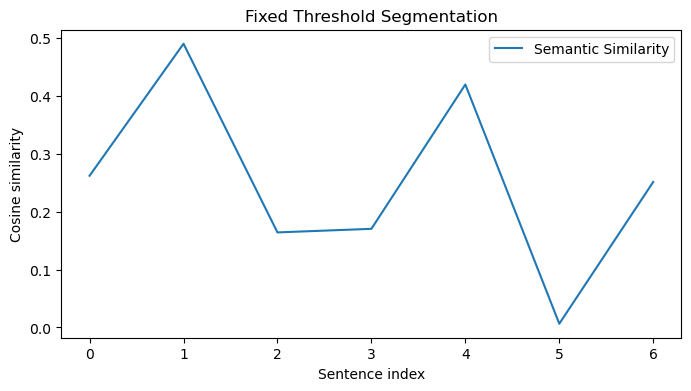

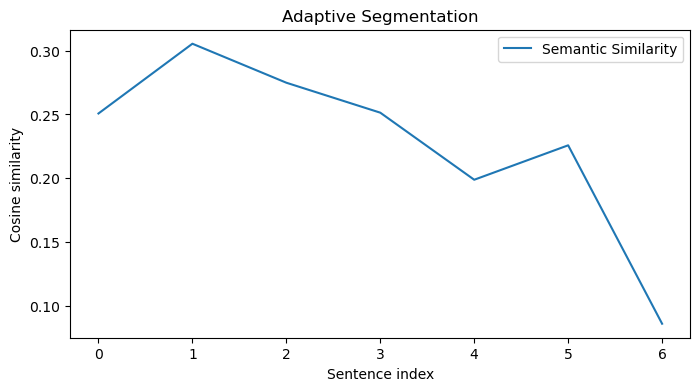

Fixed: 8 segments 
Adaptive: 1 segments
Fixed coherence: 0.000
Adaptive coherence: 0.169


In [7]:
sample_text = episode

segments_fixed, sim_fixed = segment_fixed_threshold(sample_text, model)
segments_adapt, sim_adapt, peaks = segment_adaptive(sample_text, model)

plot_similarity_curve(sim_fixed, title="Fixed Threshold Segmentation")
plot_similarity_curve(sim_adapt, peaks, title="Adaptive Segmentation")

print(f"Fixed: {len(segments_fixed)} segments \nAdaptive: {len(segments_adapt)} segments")
print(f"Fixed coherence: {segment_coherence(segments_fixed, model):.3f}")
print(f"Adaptive coherence: {segment_coherence(segments_adapt, model):.3f}")


In [10]:

print("\n" + "="*30)
print("PODCAST ADAPT_SEGMENTATION RESULTS")
print("="*30 + "\n")

for i, segment in enumerate(segments_adapt):
    print(f"--- SEGMENT {i+1} ---\n")
    print(segment)
    if i > 5:
        break
    print("\n" + "-"*20 + "\n")

print("\n" + "="*30)
print("PODCAST FIXED_SEGMENTATION RESULTS")
print("="*30 + "\n")

for i, segment in enumerate(segments_fixed):
    print(f"--- SEGMENT {i+1} ---\n")
    print(segment)
    if i > 5:
        break
    print("\n" + "-"*20 + "\n")


PODCAST ADAPT_SEGMENTATION RESULTS

--- SEGMENT 1 ---

 I'm Simon Shapiro and this is Sing Out Speak Out. Here I give you the philosophies, ideas and songs I've been working on for many years but until now I've shared just too few of because I've been afraid of you and worse I've been afraid of me. My will to connect with you and share the best of me has grown greater than any fear and that's why I am compelled to Sing Out Speak Out. Hi everyone, welcome to another episode of Sing Out Speak Out. Exciting news today, we have just released, I want to say we, I mean a couple of friends and I who are in this band called Kiss Tone that we have been in for quite a long time and for many reasons we started on this record 12 years ago and are only able to release it now and very excited that we can do it and I'm really looking forward to hearing what you think of it. I'm very proud of this record. We recorded it with the producer now very well established in Nashville producer Lindsey Rhimes 

### 2. Testing segmentation with `wtpsplit` and `SentenceBERT` (potential alternative: Status: dropped)

Here the idea is the same as **B. `segment_adaptive`** only difference is this method uses more robust `wtpsplit` (State-of-the-art sentence segmentation with 12 Transfomer layers) library for ***segment text into sentences*** compared to `nltk(punkt)`.<br>
- requirement:
    - `pip install wtpsplit`

In [11]:

def create_topical_segments(sents, embedding_model, window=3, prominence=0.05, drop_factor=0.85):
    """
    This is the "segment_adaptive" logic, but modified to accept a
    list of pre-split sentences (from wtpsplit) instead of raw text.
    
    This function finds the *thematic* breaks.
    """
    
    print(f"\nAnalyzing {len(sents)} sentences for *topical* breaks...")
    
    if len(sents) < 2: 
        return [" ".join(sents)], [], []
        
    # --- 1. Get Embeddings ---
    # We use the embedding_model (e.g., 'all-mpnet-base-v2') for this
    print("Calculating sentence embeddings...")
    embs = embedding_model.encode(sents, show_progress_bar=True)
    
    # --- 2. Calculate Adjacent Similarities ---
    print("Calculating adjacent sentence similarities...")
    sim = [util.cos_sim(embs[i], embs[i + 1]).item() for i in range(len(embs) - 1)]
    
    # --- 3. Smooth, Invert, and Find Peaks ---
    print("Smoothing signal and finding peaks (topic breaks)...")
    # Use a longer window to find bigger "paragraph" level breaks
    smooth = np.convolve(sim, np.ones(window)/window, mode="same")
    inverted = 1 - np.array(smooth)
    
    # Find peaks with a minimum prominence
    peaks, _ = find_peaks(inverted, prominence=prominence)
    
    # --- 4. Adaptive Filtering ---
    # Filter peaks to only keep "significant" drops
    mean_sim = np.mean(smooth)
    adaptive_threshold = drop_factor * mean_sim
    
    breaks = [p for p in peaks if smooth[p] < adaptive_threshold]
    
    print(f"Raw similarity scores (sample): {[round(s, 2) for s in sim[:5]]}...")
    print(f"Smoothed signal (sample): {[round(s, 2) for s in smooth[:5]]}...")
    print(f"Found {len(peaks)} local peaks (potential breaks).")
    print(f"Adaptive threshold is: {adaptive_threshold:.4f}")
    print(f"Filtered down to {len(breaks)} significant topical breaks.")

    # --- 5. Create Final Segments ---
    idx = [0] + breaks + [len(sents)]
    segs = [" ".join(sents[idx[i]:idx[i + 1]]) for i in range(len(idx) - 1)]
    
    return segs, smooth, peaks


In [12]:
print("Loading 'sat-12l-sm' (wtpsplit) model...")
sat_model = SaT("sat-12l-sm")

# Move to GPU if available
try:
    if torch.cuda.is_available():
        print("CUDA available. Moving SaT to GPU.")
        sat_model.to("cuda")
        sat_model.half()
    else:
        print("SaT running on CPU.")
except Exception as e:
    print(f"GPU setup for SaT failed: {e}")
# --- Load Model 2: The Embedding Model (SentenceTransformer) ---
print("Loading 'all-mpnet-base-v2' (embedding) model...")
# This model is specifically designed to be good at semantic similarity
embed_model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')
print("All models loaded.")
# --- Sample Data ---
sample_transcript = (
    "Welcome to 'TechForward', I'm your host, Alex. Today we're diving deep into the world of artificial intelligence. "
    "It's a field that's moving at lightning speed. Just last year, we saw models that could write poetry, and now we're seeing AI that can generate photorealistic video. "
    "It's truly a paradigm shift in content creation.\n"
    "But what does this mean for artists and creators? "
    "Many are worried about their jobs being automated. Sarah, you're an expert in AI ethics, what's your take? "
    "Well Alex, it's a valid concern, but I see it more as a tool for augmentation, not replacement. "
    "Think of it like the synthesizer in music - it didn't replace musicians, it created new genres.\n"
    "That's a great point. Let's switch gears a bit. I want to talk about hardware. "
    "None of this amazing AI would be possible without the incredible advancements in GPU technology. "
    "These new tensor cores are specifically designed for matrix multiplication, which is the heart of deep learning. "
    "It's fascinating how software and hardware are co-evolving.\n"
    "Speaking of hardware, I've just been testing the new 'QuantumByte' laptop. "
    "It's got one of these new chips, and the performance is just staggering for such a thin device. "
    "The battery life, however, is another story. I'm getting about half of what they advertised. "
    "That's always the trade-off, isn't it? Power versus longevity. "
    "For our listeners thinking of upgrading, I'd say wait for the second-gen reviews.\n"
    "Absolutely. Okay, before we wrap up, let's look at what's coming next week. "
    "We'll be interviewing the CEO of 'GreenSolar', a company revolutionizing home energy storage. "
    "They claim their new battery technology can power a home for three days straight. "
    "It's a bold claim, and we're going to dig into the science behind it. Thanks for tuning in."
)
# --- STEP 1: Get clean sentences from wtpsplit ---
# We use do_paragraph_segmentation=False to just get *sentences*
print("\n--- STEP 1: Cleaning text with wtpsplit ---")
# --- interchangeably testing with episode data and sample data (e.g. sample_transcript) 
clean_sentences = sat_model.split(episode, do_paragraph_segmentation=False)
print(f"Successfully split text into {len(clean_sentences)} clean sentences.")



# --- STEP 2: Find topical segments from the clean sentences ---
print("\n--- STEP 2: Finding topical segments with adaptive method ---")
# We can tune these parameters. A larger 'window' (e.g., 5) and
# a larger 'prominence' (e.g., 0.1) will find *fewer* and *larger* segments.
topic_segments, _, _ = create_topical_segments(
    clean_sentences, 
    embed_model,
    window=3, 
    prominence=0.05, 
    drop_factor=0.85
)
# --- Print Final Results ---
print("\n" + "="*30)
print("ROBUST TOPICAL SEGMENTATION RESULTS")
print("="*30 + "\n")

for i, segment in enumerate(topic_segments):
    print(f"--- TOPICAL SEGMENT {i+1} ---\n")
    print(segment.strip())
    print("\n" + "-"*20 + "\n")

Loading 'sat-12l-sm' (wtpsplit) model...
CUDA available. Moving SaT to GPU.
Loading 'all-mpnet-base-v2' (embedding) model...
All models loaded.

--- STEP 1: Cleaning text with wtpsplit ---
Successfully split text into 19 clean sentences.

--- STEP 2: Finding topical segments with adaptive method ---

Analyzing 19 sentences for *topical* breaks...
Calculating sentence embeddings...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Calculating adjacent sentence similarities...
Smoothing signal and finding peaks (topic breaks)...
Raw similarity scores (sample): [0.41, 0.45, 0.6, 0.32, 0.29]...
Smoothed signal (sample): [0.29, 0.49, 0.46, 0.4, 0.27]...
Found 1 local peaks (potential breaks).
Adaptive threshold is: 0.2608
Filtered down to 1 significant topical breaks.

ROBUST TOPICAL SEGMENTATION RESULTS

--- TOPICAL SEGMENT 1 ---

I'm Simon Shapiro and this is Sing Out Speak Out.  Here I give you the philosophies, ideas and songs I've been working on for many years but until now I've shared just too few of because I've been afraid of you and worse I've been afraid of me.  My will to connect with you and share the best of me has grown greater than any fear and that's why I am compelled to Sing Out Speak Out.  Hi everyone, welcome to another episode of Sing Out Speak Out.  Exciting news today, we have just released, I want to say we, I mean a couple of friends and I who are in this band called Kiss Tone that we have 

### 3. Testing segmentation with `neuralTextTiling` algorithm (potential alternative: Status: kept)

**This is the method we will use for our document segmentation**

The previous algorithms were "local," comparing $s_i$ to $s_{i+1}$. 
This TextTiling implementation is "semi-global," as it compares blocks of text.

The core idea is to compute a "boundary score" for each sentence. This score is high if the text before it is semantically different from the text after it. This calculation creates a "timeseries" graph of topic similarity. The rest of the math is just a sophisticated way to find the deepest and most significant "valleys" in that graph.

<br>

**Notation**

 - $S = [s_1, s_2, ..., s_N]$: The list of $N$ filtered sentences.
 - $E = [\vec{e}_1, \vec{e}_2, ..., \vec{e}_N]$: The list of corresponding $d$-dimensional embedding vectors, where $\vec{e}_i \in \mathbb{R}^d$.
 - $k$: The block size (e.g., $k=5$).
 - $\text{sim}(\vec{a}, \vec{b})$: The cosine similarity function, $\frac{\vec{a} \cdot \vec{b}}{\|\vec{a}\| \|\vec{b}\|}$.

<br>

**Step 1: Block Comparison Score (`block_comparison_score`)**

This function computes a "boundary score" $c_i$ for each potential gap.

The function iterates $i$ from $k$ up to $N - k - 1$. For each $i$, it defines two blocks:

1. **Block Before:** The average embedding of the $k$ sentences before $s_i$.

$$\vec{B}_{\text{before}}(i) = \frac{1}{k} \sum_{j=i-k}^{i-1} \vec{e}_j$$

2. **Block After:** The average embedding of the $k$ sentences after $s_i$.

$$\vec{B}_{\text{after}}(i) = \frac{1}{k} \sum_{j=i+1}^{i+k} \vec{e}_j$$
The similarity score $c_i$ for the gap at $s_i$ is the cosine similarity between these two average vectors:

$$c_i = \text{sim}(\vec{B}_{\text{before}}(i), \vec{B}_{\text{after}}(i))$$
This creates a new timeseries $C$ of similarity scores. This list is shorter than the original sentence list.

$$C = [c_k, c_{k+1}, ..., c_{N-k-1}]$$

Let's call the length of this list $m = N - 2k$. So, $C = [y_0, y_1, ..., y_{m-1}]$.

<br>

**Step 2: Smoothing (`smooth`)**

This step applies a moving average filter to $C$ to reduce noise. Let $C_S$ be the smoothed timeseries. For $n$ passes and a window radius $s$:
A single pass of smoothing (with $s=1$, for simplicity) calculates a new score $y'_i$ as:

$$y'_i = \frac{y_{i-1} + y_i + y_{i+1}}{3}$$

(with boundary conditions for $i=0$ and $i=m-1$).
Our code's more general formula for a window radius $s$ is:

$$y'_i = \frac{1}{|W_i|} \sum_{j \in W_i} y_j$$

where $W_i = \{j \mid \max(0, i-s) \le j \le \min(m-1, i+s)\}$. This process is repeated $n$ times.
Let the final, smoothed timeseries be $C_S = [y_0, y_1, ..., y_{m-1}]$.

<br>

**Step 3: Depth Score (`depth_score`)**

This is the most "classic TextTiling" part. For every point $y_i$ in the smoothed graph, it calculates how "deep" the valley is at that point.
For each point $y_i$ (where $0 < i < m-1$):

1. **Find Left Peak ($y_l$):** Find the index $l < i$ of the nearest "peak" to the left. The code does this by starting at $l = i-1$ and "walking left" as long as the score is increasing (i.e., $y_{l-1} > y_l$).

$$l = \min(\{ j \le i-1 \mid (y_{j-1} \le y_j \text{ and } j > 0) \text{ or } j=0 \})$$

2. **Find Right Peak ($y_r$):** Find the index $r > i$ of the nearest "peak" to the right. The code starts at $r = i+1$ and "walks right" as long as the score is increasing (i.e., $y_{r+1} > y_r$).

$$r = \max(\{ j \ge i+1 \mid (y_{j+1} \le y_j \text{ and } j < m-1) \text{ or } j=m-1 \})$$

3. **Calculate Depth ($d_i$):** The depth score is the sum of the heights of the "cliffs" on either side of the valley.

$$d_i = (y_l - y_i) + (y_r - y_i)$$
This creates a new list of depth scores $D = [d_1, ..., d_{m-2}]$.

<br>

**Step 4: Breakpoint Identification (`Thresholding`)**

Now we find the peaks of the depth_score graph. A "peak" here corresponds to the bottom of the deepest valley in the similarity graph.

1. **Find Local Maxima:** Find all indices $i$ in $D$ that are local peaks.

$$I_{\text{max}} = \{i \mid d_{i-1} < d_i \text{ and } d_i > d_{i+1}\}$$

2. **Find Max Depth:** Find the single highest depth score from these peaks.

$$d_{\max} = \max_{i \in I_{\text{max}}}(d_i)$$

3. **Calculate Threshold:** Create an adaptive threshold based on $d_{\max}$.

$$D_{\text{thresh}} = \text{threshold\_factor} \times d_{\max}$$
4. **Filter Peaks:** The final set of break indices (relative to $D$) are those peaks that clear the threshold.

$$I_{\text{breaks}} = \{i \in I_{\max} \mid d_i > D_{\text{thresh}}\}$$

<br>

**Step 5: Index Mapping**

This final step maps the indices from $I_{\text{breaks}}$ back to the original sentence list $S$.
Let's trace an index $\text{idx} \in I_{\text{breaks}}$:
- $\text{idx}$ is an index into the depth score list $D$.
- $D$ starts at index 1 of the smoothed list $C_S$. So, $\text{idx}$ corresponds to $\text{idx}+1$ in $C_S$.
- $C_S$ has the same indices as the similarity list $C$. So this is $\text{idx}+1$ in $C$.
- The similarity list $C$ starts at sentence $k$. An index $j$ in $C$ corresponds to the score for sentence $s_{k+j}$.
- Therefore, our index $\text{idx}+1$ in $C$ corresponds to the original sentence:

$$\text{Sentence Index} = k + (\text{idx} + 1)$$


### Implementation: segmentation with `neuralTextTiling` algorithm

In [ ]:
from wtpsplit import SaT
from sentence_transformers import SentenceTransformer, util
# --- Model Loading ---
# We load both models globally to be efficient.

# Model 1: For splitting text into clean sentences
print("Loading 'sat-12l-sm' (wtpsplit) model...")
sat_model = SaT("sat-12l-sm")

# Model 2: For getting sentence embeddings
print("Loading 'all-mpnet-base-v2' (embedding) model...")
embed_model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')

# Move models to GPU if available
try:
    if torch.cuda.is_available():
        print("CUDA available. Moving models to GPU.")
        sat_model.to("cuda")
        sat_model.half()
        embed_model.to("cuda")
    else:
        print("Running on CPU.")
except Exception as e:
    print(f"GPU setup failed: {e}")

# --- TextTiling Algorithm Functions (from paper) ---

def block_comparison_score(embs_stack, k=10): # <-- PARAMETER RENAMED
    """
    Implements the block comparison from TextTiling.
    Calculates similarity score for each "gap" between sentences.
    
    Args:
        embs_stack (torch.Tensor): A 2D Tensor of (num_sentences, emb_dim).
                                   This is PRE-STACKED.
        k (int): The block size (number of sentences to compare on
                 either side of the gap).
    
    Returns:
        list[float]: A list of similarity scores.
    """
    if len(embs_stack) < k * 2:
        # Not enough sentences to compare
        return []
        
    scores = []
    
    # Iterate from the first possible gap (after k sentences)
    # to the last possible gap (before k sentences from the end)
    for i in range(k, len(embs_stack) - k):
        # Score gap at (i): compare [s(i-k)...s(i-1)] with [s(i+1)...s(i+k)].
        
        # Block before: k sentences ending at i
        block_before = embs_stack[i-k : i]
        
        # Block after: k sentences starting at i+1
        block_after = embs_stack[i+1 : i+k+1]
        
        # Pool the embeddings (average) to get a topic vector
        pool_before = torch.mean(block_before, dim=0)
        pool_after = torch.mean(block_after, dim=0)
        
        # Calculate cosine similarity
        sim = util.cos_sim(pool_before, pool_after).item()
        scores.append(sim)
        
    return scores

def depth_score(timeseries):
    """
    Calculates the "depth" of each valley (potential break).
    A deep valley means a significant topic change.
    (This function is a direct implementation from the paper's core.py)
    """
    depth_scores = []
    for i in range(1, len(timeseries) - 1):
        left, right = i - 1, i + 1
        while left > 0 and timeseries[left - 1] > timeseries[left]:
            left -= 1
        while (
            right < (len(timeseries) - 1) and timeseries[right + 1] > timeseries[right]
        ):
            right += 1
        
        # Score is the sum of the "cliffs" on either side
        depth = (timeseries[left] - timeseries[i]) + (timeseries[right] - timeseries[i])
        depth_scores.append(depth)
    return depth_scores

def smooth(timeseries, n=2, s=1):
    """
    Applies a simple moving average filter.
    (This function is from the paper's core.py)
    """
    if not timeseries:
        return []
    smoothed_timeseries = timeseries[:]
    for _ in range(n):
        for index in range(len(smoothed_timeseries)):
            neighbours = smoothed_timeseries[
                max(0, index - s) : min(len(timeseries) - 1, index + s) + 1
            ]
            smoothed_timeseries[index] = sum(neighbours) / len(neighbours)
    return smoothed_timeseries

def get_local_maxima(array):
    """
    Finds local maxima (peaks) in a list.
    (This function is from the paper's core.py)
    """
    local_maxima_indices = []
    local_maxima_values = []
    for i in range(1, len(array) - 1):
        if array[i - 1] < array[i] and array[i] > array[i + 1]:
            local_maxima_indices.append(i)
            local_maxima_values.append(array[i])
    return local_maxima_indices, local_maxima_values

# --- Main Segmentation Function ---

def find_topical_segments(
    text, 
    k=5, 
    min_sentence_len=4,
    smooth_passes=1, 
    smooth_window=1, 
    threshold_factor=0.6
):
    """
    Combines all steps into the full hybrid pipeline.
    
    Args:
        text (str): The full podcast transcript.
        k (int): The block size for TextTiling.
        min_sentence_len (int): Filter out sentences shorter than this.
        smooth_passes (int): Number of smoothing passes.
        smooth_window (int): Window size for smoothing.
        threshold_factor (float): Threshold for break detection, as a
                                  factor of the max depth score.
    
    Returns:
        list[str]: The final list of topic segments.
        dict: A dictionary of intermediate scores for plotting.
    """
    
    # --- Step 1: Clean sentences with wtpsplit ---
    print("\n--- 1. Cleaning text with wtpsplit ---")
    sents = sat_model.split(text, do_paragraph_segmentation=False)
    print(f"Found {len(sents)} raw sentences.")

    # --- Step 2: Pre-process and Filter (CRITICAL) ---
    # This is from the paper: filter out very short,
    # non-semantic "noise" sentences.
    original_sents = sents
    sents = [s.strip() for s in sents if len(s.split()) > min_sentence_len]
    print(f"Filtered down to {len(sents)} sentences (>{min_sentence_len} words).")
    
    if len(sents) < k * 2:
        print("Not enough sentences to perform segmentation.")
        return [" ".join(original_sents)], {}
    
    # --- Step 3: Get Embeddings ---
    print("\n--- 2. Calculating Embeddings ---")
    embs = embed_model.encode(
        sents, 
        convert_to_tensor=True, 
        show_progress_bar=True
    )

    # --- Step 4: Run TextTiling Algorithm ---
    print("\n--- 3. Running TextTiling Algorithm ---")
    
    # 4a. Get block comparison scores
    sim_scores = block_comparison_score(embs, k=k) # 'embs' is already a stack
    
    # 4b. Smooth the scores
    smooth_scores = smooth(sim_scores, n=smooth_passes, s=smooth_window)
    
    # 4c. Calculate "depth" of valleys
    depth_scores = depth_score(smooth_scores)
    
    print(f"Calculated {len(sim_scores)} block similarity scores.")
    print(f"Calculated {len(depth_scores)} depth scores.")

    # --- Step 5: Find Breakpoints (Thresholding) ---
    print("\n--- 4. Finding Breakpoints ---")
    
    # Find the peaks of the depth scores
    local_maxima_indices, local_maxima_values = get_local_maxima(depth_scores)
    
    if not local_maxima_values:
        print("No significant breaks found.")
        return [" ".join(original_sents)], {}

    # Adaptive threshold:
    # A break must be at least 60% as "deep" as the deepest break.
    threshold = threshold_factor * max(local_maxima_values)
    
    # Find all breaks that pass the threshold
    break_indices = [
        local_maxima_indices[i] 
        for i, val in enumerate(local_maxima_values) 
        if val > threshold
    ]
    
    print(f"Found {len(local_maxima_indices)} potential breaks.")
    print(f"Max depth score: {max(local_maxima_values):.4f}")
    print(f"Calculated threshold: {threshold:.4f}")
    print(f"Filtered down to {len(break_indices)} final breaks.")

    # --- Step 6: Map indices and create segments ---
    print("\n--- 5. Creating Final Segments ---")
    
    # This maps the depth_score indices back to the original sentence indices.
    # A depth_score index 'idx' corresponds to a sim_score index 'idx+1'.
    # A sim_score index 'idx' corresponds to a sentence gap 'idx+k'.
    final_break_indices = [k + idx + 1 for idx in break_indices]
    
    # Create the final list of "slice" points
    idx_list = sorted(list(set([0] + final_break_indices + [len(sents)])))
    
    segments = []
    for i in range(len(idx_list) - 1):
        start = idx_list[i]
        end = idx_list[i+1]
        segments.append(" ".join(sents[start:end]))
        
    # Data for plotting
    plot_data = {
        'sim_scores': sim_scores,
        'smooth_scores': smooth_scores,
        'depth_scores': depth_scores,
        'threshold': threshold,
        'breaks': break_indices,
        'score_x_axis': list(range(len(depth_scores))),
        'break_x_axis': break_indices
    }
        
    return segments, plot_data

def plot_segmentation_scores(plot_data, k=5):
    """
    Uses matplotlib to visualize the algorithm's scores.
    """
    if not plot_data:
        print("\nNo plot data to show.")
        return
        
    print("\nGenerating plot...")
    
    sim_scores = plot_data['sim_scores']
    smooth_scores = plot_data['smooth_scores']
    depth_scores = plot_data['depth_scores']
    threshold = plot_data['threshold']
    break_x_axis = plot_data['break_x_axis']

    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(12, 8))
    fig.suptitle('Hybrid TextTiling Segmentation Analysis', fontsize=16)

    # --- Plot 1: Similarity Scores ---
    # X-axis needs to be offset to align with gaps
    sim_x_axis = [i + k for i in range(len(sim_scores))]
    smooth_x_axis = [i + k for i in range(len(smooth_scores))]

    ax1.plot(sim_x_axis, sim_scores, 'b-', label='Raw Similarity')
    ax1.plot(smooth_x_axis, smooth_scores, 'r-', linewidth=2, label='Smoothed Similarity')
    ax1.set_ylabel('Similarity (Higher is similar)')
    ax1.set_title('Block Similarity Scores (Valleys = Topic Breaks)')
    ax1.legend()
    ax1.grid(True, linestyle=':')

    # --- Plot 2: Depth Scores ---
    # X-axis needs to be offset to align with gaps
    depth_x_axis = [i + k + 1 for i in range(len(depth_scores))]
    
    ax2.plot(depth_x_axis, depth_scores, 'g-', linewidth=2, label='Valley Depth Score')
    ax2.plot(
        depth_x_axis, 
        [threshold] * len(depth_scores), 
        'r--', 
        label=f'Threshold ({threshold:.2f})'
    )
    
    # Plot the breaks we found
    break_points_x = [depth_x_axis[i] for i in break_x_axis]
    break_points_y = [depth_scores[i] for i in break_x_axis]
    ax2.plot(break_points_x, break_points_y, 'kx', markersize=10, mew=3, label='Final Topic Break')
    
    ax2.set_xlabel('Sentence Gap Index')
    ax2.set_ylabel('Depth Score (Higher is better break)')
    ax2.set_title('Depth Score Analysis (Peaks = Topic Breaks)')
    ax2.legend()
    ax2.grid(True, linestyle=':')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    #plt.savefig("segmentation_plot.png")
    print("Plot saved to segmentation_plot.png")
    # To display the plot in a notebook, you might use plt.show()
    plt.show()


Loading 'sat-12l-sm' (wtpsplit) model...
Loading 'all-mpnet-base-v2' (embedding) model...
GPU setup failed: name 'torch' is not defined


In [ ]:

# --- Set Hyperparameters ---
# For a long podcast, the paper's default of k=15 is better.
K_BLOCK_SIZE = 5           # How many sentences in a block
MIN_SENTENCE_LEN = 3     # Filter sentences shorter than 3 words
SMOOTH_PASSES = 1        # Number of smoothing passes
SMOOTH_WINDOW = 1        # Window for smoothing
THRESHOLD_FACTOR = 0.5   # 0.6 = break must be 60% of max depth

# ----------------------at this point more hyperparameter testing is required--------------------------

# --- C. Run Full Pipeline ---
segments, plot_data = find_topical_segments(
    episode,
    k=K_BLOCK_SIZE,
    min_sentence_len=MIN_SENTENCE_LEN,
    smooth_passes=SMOOTH_PASSES,
    smooth_window=SMOOTH_WINDOW,
    threshold_factor=THRESHOLD_FACTOR
)
# --- D. Print Results ---
print("\n" + "="*30)
print("HYBRID TEXTTILING SEGMENTATION RESULTS")
print("="*30 + "\n")

for i, segment in enumerate(segments):
    print(f"--- TOPICAL SEGMENT {i+1} ---\n")
    print(segment.strip())
    print("\n" + "-"*20 + "\n")
# --- E. Plot Results ---
if 'plt' in globals():
    plot_segmentation_scores(plot_data, k=K_BLOCK_SIZE)
else:
    print("\nMatplotlib not installed. Skipping plot.")
    print("To see the plot, run: pip install matplotlib")

<p style="color:red"><strong><em>Overall, the third method for segmentation with more advanced <code>nuralTextTiling Algorithm</code> does much better job at segmenting the transcript with better precision and much much more robust to noise(e.g. 'brilliant', 'aah', 'let me know'...)</em></strong></p> 

# Compact pipeline

In [ ]:
import os
import glob
import numpy as np

# --- Run the harveser.py ---
# it creates simantic segmentation and pre-compute the embeddings for topic modeling.
# embeddings will be saved in the processe_vectorss folder. Single ".npy" file for each episode
# the idea is to segment locally for each episode with varied lengths since hyperparameter K in our TexTilling algorithm is
# very sensitive to length. 

# --- Load the Harvested Vectors ---
VECTOR_DIR = "processed_vectors"
files = sorted(glob.glob(os.path.join(VECTOR_DIR, "*.npy")))

all_texts = []       # saves all the segments from each episode for every episode
all_embeddings = []  # saves all the eembeddings from each episode for every episode
timestamps = []      # To track which episode each segment belongs to
episode_names = []   # To track episode IDs

print("Loading data...")
for fpath in files:
    # Load the .npy file
    data = np.load(fpath, allow_pickle=True).item()
    
    # Extract data
    vectors = data['vectors']          # The embeddings
    snippets = data['text_snippets']   # The text segments
    ep_id = data.get('episode_id', os.path.basename(fpath))
    
    # Append to our global lists
    # Note: We assume 'vectors' and 'snippets' are aligned lists/arrays
    for i, vec in enumerate(vectors):
        all_texts.append(snippets[i])
        all_embeddings.append(vec)
        episode_names.append(ep_id)
        timestamps.append(i) # Simple index as timestamp proxy

# Convert embeddings to a single numpy array
# BERTopic expects shape (n_samples, embedding_dim)
X_embeddings = np.array(all_embeddings)

print(f"Loaded {len(all_texts)} total segments.")
print(f"Embedding Matrix Shape: {X_embeddings.shape}")

Loading data...
Loaded 1006 total segments.
Embedding Matrix Shape: (1006, 768)


### Topic Modeling (BERTopic)

In [2]:

from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sentence_transformers import SentenceTransformer

from sklearn.feature_extraction.text import CountVectorizer
from bertopic.vectorizers import ClassTfidfTransformer
from bertopic.representation import KeyBERTInspired

# Step 1 - Extract embeddings
embedding_model = SentenceTransformer("all-mpnet-base-v2")

# Step 2 - Reduce dimensionality
umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)

# Step 3 - Cluster reduced embeddings
hdbscan_model = HDBSCAN(min_cluster_size=15, metric='euclidean', cluster_selection_method='eom', prediction_data=True)

# Step 4 - Tokenize topics
vectorizer_model = CountVectorizer(stop_words="english")

# Step 5 - Create topic representation
ctfidf_model = ClassTfidfTransformer()

# Step 6 - (Optional) Fine-tune topic representations with
# a `bertopic.representation` model
representation_model = KeyBERTInspired()

# All steps together
topic_model = BERTopic(
  embedding_model=embedding_model,          # Step 1 - Extract embeddings
  umap_model=umap_model,                    # Step 2 - Reduce dimensionality
  hdbscan_model=hdbscan_model,              # Step 3 - Cluster reduced embeddings
  vectorizer_model=vectorizer_model,        # Step 4 - Tokenize topics
  ctfidf_model=ctfidf_model,                # Step 5 - Extract topic words
  representation_model=representation_model, # Step 6 - (Optional) Fine-tune topic representations
  verbose = True
)

topics, probs = topic_model.fit_transform(all_texts, X_embeddings)
topic_model.get_topic_info()

c:\Users\Sadik\Desktop\NLP Project\project-milestone-p2-group-10\Tmodel\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-11-28 09:45:07,208 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-11-28 09:45:14,748 - BERTopic - Dimensionality - Completed ✓
2025-11-28 09:45:14,748 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-11-28 09:45:14,769 - BERTopic - Cluster - Completed ✓
2025-11-28 09:45:14,788 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-11-28 09:45:15,959 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,136,-1_life_heal_listening_positivity,"[life, heal, listening, positivity, culture, p...",[You know what I'm going to let you guys go fi...
1,0,210,0_sermon_read_passage_chapter,"[sermon, read, passage, chapter, bible, approa...","[Our God is greater, our God is stronger, God ..."
2,1,108,1_scenario_conversation_africa_kind,"[scenario, conversation, africa, kind, underst...",[ This conversation on COVID-19 is made possib...
3,2,90,2_podcast_speaking_episode_words,"[podcast, speaking, episode, words, story, app...","[Welcome everyone to this Epic Life, the podca..."
4,3,79,3_wacows_isolation_tower_situation,"[wacows, isolation, tower, situation, address,...","[You pop that spark yet? Oh, I like it. You'..."
5,4,68,4_health_community_leaders_impacted,"[health, community, leaders, impacted, evidenc...","[I do want to mention, I know I kind of mentio..."
6,5,49,5_resilience_riots_outbreak_afford,"[resilience, riots, outbreak, afford, inequiti...",[Stories from a pandemic. Search outbreak Ala...
7,6,45,6_progress_philosophies_announcement_news,"[progress, philosophies, announcement, news, f...",[ Hello hello hello you are now listening to s...
8,7,37,7_illnesses_slogans_conclusion_unrest,"[illnesses, slogans, conclusion, unrest, prote...","[ On May 25th, 2020, George Perry Floyd died a..."
9,8,36,8_outcomes_fears_anxiety_dealing,"[outcomes, fears, anxiety, dealing, affected, ...",[Hello and welcome to the Anxiety to Confidenc...


In [ ]:
umap_model_new = UMAP(n_neighbors=25, n_components=5, min_dist=0.0, metric='cosine', random_state=42)
topic_model.umap_model = umap_model_new
topics, probs = topic_model.fit_transform(all_texts, X_embeddings)
topic_model.get_topic_info()

In [ ]:
from sklearn.cluster import KMeans

MIN_CLUSTER_SIZE= 35
MIN_SAMPLES = 10
hdbscan_model = HDBSCAN(
    min_cluster_size=MIN_CLUSTER_SIZE,
    metric='euclidean',
    cluster_selection_method='eom',
    min_samples=MIN_SAMPLES
)

#Kmeans_model = KMeans(n_clusters=15)
topic_model.hdbscan_model = hdbscan_model
topics, _ = topic_model.fit_transform(all_texts, X_embeddings)
topic_model.get_topic_info()

In [3]:
topic_model.update_topics(all_texts, vectorizer_model=CountVectorizer(stop_words="english", ngram_range=(2,3)))
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,136,-1_having great_great day episode_great great_...,"[having great, great day episode, great great,...",[You know what I'm going to let you guys go fi...
1,0,210,0_little bit_today episode_god god_welcome ffgf,"[little bit, today episode, god god, welcome f...","[Our God is greater, our God is stronger, God ..."
2,1,108,1_covid 19_conversation covid 19_alec hogg_cov...,"[covid 19, conversation covid 19, alec hogg, c...",[ This conversation on COVID-19 is made possib...
3,2,90,2_epic life_life podcast_epic life podcast_bai...,"[epic life, life podcast, epic life podcast, b...","[Welcome everyone to this Epic Life, the podca..."
4,3,79,3_don know_like don_like like_like look,"[don know, like don, like like, like look, fig...","[You pop that spark yet? Oh, I like it. You'..."
5,4,68,4_little bit_want stick_invite lot_really unique,"[little bit, want stick, invite lot, really un...","[I do want to mention, I know I kind of mentio..."
6,5,49,5_alabama itunes podcasts_itunes podcasts_know...,"[alabama itunes podcasts, itunes podcasts, kno...",[Stories from a pandemic. Search outbreak Ala...
7,6,45,6_music music_music music music_hello hello_gr...,"[music music, music music music, hello hello, ...",[ Hello hello hello you are now listening to s...
8,7,37,7_people saying_um yeah_yesterday watched prem...,"[people saying, um yeah, yesterday watched pre...","[ On May 25th, 2020, George Perry Floyd died a..."
9,8,36,8_confidence podcast_hello welcome anxiety_con...,"[confidence podcast, hello welcome anxiety, co...",[Hello and welcome to the Anxiety to Confidenc...


In [4]:
import spacy
from typing import List

class ImprovedTokenizer:
    def __init__(self):
        self.nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])
        self.MEANINGFUL_BIGRAMS = {
            ("ADJ", "NOUN"),
            ("NOUN", "NOUN"),
            ("VERB", "NOUN"),
        }
    # Keep only the most meaningful syntactic bigram patterns
    def __call__(self, text: str, max_tokens=200) -> List[str]:
        doc = self.nlp(text[:3000])  # truncate long docs for speed
        tokens = [(t.text, t.lemma_.lower(), t.pos_) for t in doc if t.is_alpha]
       
        bigrams = []
        for i in range(len(tokens) - 1):
            word1, lemma1, pos1 = tokens[i]
            word2, lemma2, pos2 = tokens[i + 1]
            if (pos1, pos2) in self.MEANINGFUL_BIGRAMS:
                # Optionally lowercase both words to normalize
                bigrams.append(f"{lemma1} {lemma2}")
       
        return bigrams
topic_model.update_topics(docs=all_texts,vectorizer_model=CountVectorizer(tokenizer=ImprovedTokenizer()))
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,136,-1_core essence_couple year_awesome t_build ma...,"[core essence, couple year, awesome t, build m...",[You know what I'm going to let you guys go fi...
1,0,210,0_abandon attitude_atheist perspective_catch f...,"[abandon attitude, atheist perspective, catch ...","[Our God is greater, our God is stronger, God ..."
2,1,108,1_active scenario_bar outshoot_budget today_ba...,"[active scenario, bar outshoot, budget today, ...",[ This conversation on COVID-19 is made possib...
3,2,90,2_epic life_bailey bena_bena andrade_big piece,"[epic life, bailey bena, bena andrade, big pie...","[Welcome everyone to this Epic Life, the podca..."
4,3,79,3_bad episode_age gap_bad food_different language,"[bad episode, age gap, bad food, different lan...","[You pop that spark yet? Oh, I like it. You'..."
5,4,68,4_live event_little bit_actual client_child life,"[live event, little bit, actual client, child ...","[I do want to mention, I know I kind of mentio..."
6,5,49,5_word podcast_follow music_folklore proj_comp...,"[word podcast, follow music, folklore proj, co...",[Stories from a pandemic. Search outbreak Ala...
7,6,45,6_music music_go t_couple week_dang thing,"[music music, go t, couple week, dang thing, d...",[ Hello hello hello you are now listening to s...
8,7,37,7_break people_central point_conclusion trump_...,"[break people, central point, conclusion trump...","[ On May 25th, 2020, George Perry Floyd died a..."
9,8,36,8_confidence podcast_different type_common thi...,"[confidence podcast, different type, common th...",[Hello and welcome to the Anxiety to Confidenc...


In [ ]:
topic_model.get_document_info(all_texts).head()

In [ ]:
topic_model.topics_

In [5]:
import openai
from bertopic.representation import OpenAI

client = openai.OpenAI(
    base_url="http://localhost:1234/v1",
    api_key="lmstudio"
    )

prompt = """
I have a topic represented by the following keywords: [KEYWORDS].
What is a good, short title for this topic? Give me only the title and nothing else.
"""
# Now, initialize the BERTopic model with your local client
representation_model = OpenAI(
    client=client,
    model="local-model",  # LMStudio ignores this; it uses the model you loaded
    delay_in_seconds=2,   # Good to prevent spamming your local server
    prompt=prompt         # Pass your custom prompt
)

topic_model.update_topics(all_texts, representation_model=representation_model)
topic_model.get_topic_info()

100%|██████████| 16/16 [00:39<00:00,  2.47s/it]


,Topic,Count,Name,Representation,Representative_Docs
0,-1,136,-1_General Discourse,[General Discourse],[You know what I'm going to let you guys go fi...
1,0,210,0_Religious Concepts,[Religious Concepts],"[Our God is greater, our God is stronger, God ..."
2,1,108,1_COVID-19 Discovery Conversation,[COVID-19 Discovery Conversation],[ This conversation on COVID-19 is made possib...
3,2,90,2_General Discourse,[General Discourse],"[Welcome everyone to this Epic Life, the podca..."
4,3,79,3_Basic Language Elements,[Basic Language Elements],"[You pop that spark yet? Oh, I like it. You'..."
5,4,68,4_Client Communication,[Client Communication],"[I do want to mention, I know I kind of mentio..."
6,5,49,5_Alabama Podcast Discussion,[Alabama Podcast Discussion],[Stories from a pandemic. Search outbreak Ala...
7,6,45,6_Music Podcast,[Music Podcast],[ Hello hello hello you are now listening to s...
8,7,37,7_Trump Protest Policing,[Trump Protest Policing],"[ On May 25th, 2020, George Perry Floyd died a..."
9,8,36,8_Anxiety and Confidence in Hosting,[Anxiety and Confidence in Hosting],[Hello and welcome to the Anxiety to Confidenc...


In [ ]:
df = topic_model.get_topic_info()

In [ ]:
df["Representation"]

## Graph modeling

In [8]:
from collections import Counter
# 1. Get the list of IDs (The list you just showed me)
raw_topic_ids = topic_model.topics_

# 2. Create a "Lookup Dictionary" for Topic Names
# This maps ID 0 -> "0_music_crazy", ID 2 -> "2_fear_response", etc.
# We skip the specific words and just grab the full name or custom label.
topic_info = topic_model.get_topic_info()
id_to_name_map = dict(zip(topic_info['Topic'], topic_info['Name']))

# 3. Convert your ID list into a Name list
# This creates the list: ["Fear Response", "Music", "Music", "Silence", ...]
named_topic_timeline = [id_to_name_map[t_id] for t_id in raw_topic_ids]


# Create transitions (Current Topic -> Next Topic)
transitions = list(zip(named_topic_timeline, named_topic_timeline[1:]))

# 4. BUILD THE NETWORKX GRAPH
# ---------------------------------------------------------
# Initialize a Directed Graph (DiGraph) because A->B is different from B->A
G = nx.DiGraph()

transition_count = Counter(transitions)
# Add edges with weights based on our counts
for (source, target), count in transition_count.items():
    G.add_edge(source, target, weight=count)

# 5. INSPECT THE RESULT
# ---------------------------------------------------------
print(f"Nodes (Topics): {G.number_of_nodes()}")
print(f"Edges (Transitions): {G.number_of_edges()}")

print("\n--- Top Transitions (Edges) ---")
# Sort edges by weight to see the most common flows
sorted_edges = sorted(G.edges(data=True), key=lambda x: x[2]['weight'], reverse=True)

for source, target, data in sorted_edges:
    print(f"{source} --> {target} : {data['weight']} times")

# 6. (OPTIONAL) CALCULATE CENTRALITY
# ---------------------------------------------------------
# Which topic is the central "hub" of the conversation?
print("\n--- Topic Centrality (Degree) ---")
degree_centrality = nx.degree_centrality(G)
# Sort by highest centrality
for topic, score in sorted(degree_centrality.items(), key=lambda item: item[1], reverse=True):
    print(f"{topic}: {score:.2f}")

Nodes (Topics): 16
Edges (Transitions): 121

--- Top Transitions (Edges) ---
0_Religious Concepts --> 0_Religious Concepts : 180 times
1_COVID-19 Discovery Conversation --> 1_COVID-19 Discovery Conversation : 88 times
2_General Discourse --> 2_General Discourse : 71 times
-1_General Discourse --> -1_General Discourse : 70 times
3_Basic Language Elements --> 3_Basic Language Elements : 64 times
4_Client Communication --> 4_Client Communication : 57 times
8_Anxiety and Confidence in Hosting --> 8_Anxiety and Confidence in Hosting : 30 times
9_Bengali Kitchen & Puchka --> 9_Bengali Kitchen & Puchka : 29 times
5_Alabama Podcast Discussion --> 5_Alabama Podcast Discussion : 26 times
7_Trump Protest Policing --> 7_Trump Protest Policing : 25 times
10_Music and Weight --> 10_Music and Weight : 24 times
11_Personal Preferences & Experiences --> 11_Personal Preferences & Experiences : 23 times
12_Success & Love Strategies --> 12_Success & Love Strategies : 16 times
-1_General Discourse --> 6_Mu

### Visualization

In [22]:
import plotly.graph_objects as go

# 1. SETUP: Get Unique Nodes and Map to Integers
# ---------------------------------------------------------
# Get all unique nodes from your graph
all_nodes = list(G.nodes())

# Create a map: {"Intro": 0, "AI Ethics": 1, ...}
node_to_index = {name: i for i, name in enumerate(all_nodes)}

color_palette = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", 
    "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf",
    "#aec7e8", "#ffbb78", "#98df8a", "#ff9896", "#c5b0d5"
]

# Assign a color to each node (cycling through the palette)
node_colors = [color_palette[i % len(color_palette)] for i in range(len(all_nodes))]

# 2. PREPARE LISTS FOR PLOTLY
# ---------------------------------------------------------
source_indices = []
target_indices = []
link_colors = []
values = []
labels = all_nodes  # This list maps 0 -> Label, 1 -> Label...

# Iterate through your graph edges
for source, target, data in G.edges(data=True):

    if source == target:
        continue

    weight = data['weight']
    
    # FILTER (Optional but Recommended):
    # If the graph is too messy, uncomment the line below to show only
    # transitions that happened more than once.
    source_hex = node_colors[node_to_index[source]]
    if weight > 3: 
    
        source_indices.append(node_to_index[source])
        target_indices.append(node_to_index[target])
        values.append(weight)
        link_colors.append(source_hex)

# 3. GENERATE THE SANKEY DIAGRAM
# ---------------------------------------------------------
fig = go.Figure(data=[go.Sankey(
    valueformat = ".0f",
    valuesuffix = "TWh",
    # Define the Nodes (The vertical blocks)
    arrangement = "snap",
    node = dict(
        pad = 15,
        thickness = 20,
        line = dict(color = "black", width = 0.5),
        label = labels,
        color = node_colors,  # You can replace this with a list of hex colors if you want specific colors
        align = "left"
    ),
    # Define the Links (The flowing streams)
    link = dict(
        source = source_indices, # The origin node index
        target = target_indices, # The destination node index
        value = values,          # The width of the stream (weight)
        color = link_colors
    )
)])

# 4. CUSTOMIZE AND SHOW
# ---------------------------------------------------------
fig.update_layout(
    title_text="Podcast Topic Flow Structure", 
    font_size=12,
    width= 1400,   # Width in pixels (Default is usually ~700)
    height= 550    # Height in pixels (Default is usually ~450)
    )
fig.show()